# Environmental Impacts on UK Mental Health
**Role framing:** Senior Research Associate (Data Science) interview task.

This notebook demonstrates a reproducible workflow combining: problem framing, synthetic microdata simulation, machine learning, and model explainability for a UK environmental mental health use case.

## Problem Framing
Research objective: quantify how environmental pollution exposure (NO2) and deprivation relate to mental health burden (PHQ-9).

**Important caution: ecological fallacy.** Area-level pollutant statistics do not automatically imply identical individual-level effects. This notebook uses synthetic *individual-level* records to illustrate an analytical approach while preserving that methodological caveat.

## Methodology
1. Load DEFRA AURN pollutant data
2. Simulate 1,000 individuals with demographic, deprivation, and environment factors.
3. Construct PHQ-9 target where higher NO2 and higher deprivation increase expected score.
4. Train a Random Forest Regressor to predict PHQ-9.
5. Use SHAP values for global and local interpretability.

## DEFRA AURN N02 PM2.5, PM10 Dataset

DEFRA's Automatic Urban and Rural Network [(AURN dataset)](https://uk-air.defra.gov.uk/networks/network-info?view=aurn).

### Monitoring Sites

- Lincoln Canwick Road
- Immingham Woodlands Avenue
- Scunthorpe Town Rowland Road
- Toft Newton Reservior (near Market Rasen)
- Tallington River Welland (near Stamford)

| Site Name (UK-AIR ID)           | DEFRA Environment Type | Category        | Pollutants (NO2, PM2.5, PM10) |  Rationale |
|---------------------------------|--------------------------|-----------------------|-------------------------------|--------------------|
| Lincoln Canwick Road (UKA00561) | Urban Traffic            | Small Urban-Deprived  | NO2                           | High-density urban roadside traffic-heavy |
| Scunthorpe Town (UKA00381)      | Urban Industrial         | Small Urban-Deprived  | NO2, PM2.5, PM10              | Industrial urban setting situated near heavy industry (steelworks). |
| Immingham Woodlands Avenue (UKA00647)  | Urban Background         | Coastal Industrial    | NO2, PM2.5, PM10              | Industrial urban setting with persistent inequalities near docks and oil refinery. |
| Toft Newton (UKA01026)          | Rural Background         | Rural                 | NO2, PM2.5, PM10              | Rural baseline clean air environment. |
| Tallington (UKA01038)           | Rural Background         | Rural                 | PM2.5, PM10                   | Analyses the impact of transport infrastructure on rural areas (near trunk road). |


### Pollutants
- Nitrogen dioxide NO2
- PM 2.5 (fine particulate matter with a diameter of less than 2.5 micrometres, 1/400th mm)
- PM 10 (fine particulate matter with a diameter of less than 10 micrometres)

In literature link between high levels of NO2, PM2.5 and PM 10 to mental health disorders:
- [Roberts, S. et al. "Exploration of NO2 and PM2.5 air pollution and mental health problems using high-resolution data in London-based children from a UK longitudinal cohort study." Psychiatry Research, 272, 8–17.](https://www.sciencedirect.com/science/article/pii/S016517811830800X)
- [Newbury, J. B. et al. "Association between air pollution exposure and mental health service use among individuals with first presentations of psychotic and mood disorders: retrospective cohort study." The British Journal of Psychiatry, 219(6), 678–685.](https://www.cambridge.org/core/journals/the-british-journal-of-psychiatry/article/association-between-air-pollution-exposure-and-mental-health-service-use-among-individuals-with-first-presentations-of-psychotic-and-mood-disorders-retrospective-cohort-study/010F283B9107A5F04C51F90B5D5F96D6)
- [Gao, Xu, et al. "Long-term air pollution, genetic susceptibility, and the risk of depression and anxiety: a prospective study in the UK Biobank cohort." Environmental health perspectives 131.1 (2023): 017002.](https://pmc.ncbi.nlm.nih.gov/articles/PMC9812022/)

Loads the data from the dataset csv files.

In [41]:
import pandas as pd
import numpy as np
from pathlib import Path

# Resolve dataset root robustly whether notebook is run from /home/cheddar or /home/cheddar/code/mental_health_ml
candidate_dirs = [
    Path('code/mental_health_ml/datasets/arun'),
    Path('datasets/arun'),
    Path('/home/cheddar/code/mental_health_ml/datasets/arun')
]
base_dir = next((p for p in candidate_dirs if p.exists()), candidate_dirs[-1])

# Friendly site labels for reporting/plots
site_label_map = {
    'immingham': 'Immingham Woodlands',
    'lincoln': 'Lincoln Canwick Road',
    'scunthorpe': 'Scunthorpe Town',
    'tallington': 'Tallington',
    'toft_newton': 'Toft Newton'
}

def infer_pollutant_from_filename(file_name: str) -> str:
    name = file_name.upper()
    if 'NO2' in name:
        return 'NO2'
    if 'PM10' in name:
        return 'PM10'
    if 'PM25' in name or 'PM2.5' in name:
        return 'PM2.5'
    return 'UNKNOWN'

def parse_24h_timestamp(date_series: pd.Series, hour_series: pd.Series) -> pd.Series:
    # DEFRA format uses hour-ending notation and may include 24:00.
    d = pd.to_datetime(date_series, format='%d-%m-%Y', errors='coerce')
    h = hour_series.astype(str).str.strip()
    is_24 = h.eq('24:00')
    h = h.where(~is_24, '00:00')
    dt = pd.to_datetime(d.dt.strftime('%Y-%m-%d') + ' ' + h, format='%Y-%m-%d %H:%M', errors='coerce')
    dt = dt.where(~is_24, dt + pd.Timedelta(days=1))
    return dt

records = []
files_found = sorted(base_dir.rglob('*.csv'))

for f in files_found:
    pollutant = infer_pollutant_from_filename(f.name)
    site_folder = f.parent.name.lower()
    site_name = site_label_map.get(site_folder, f.parent.name)

    # Data starts after 4 metadata lines in these UK-AIR exports.
    raw = pd.read_csv(f, skiprows=4, dtype=str)
    raw.columns = [str(c).strip() for c in raw.columns]

    # First column is date, subsequent columns are hourly values.
    date_col = raw.columns[0]
    raw = raw.rename(columns={date_col: 'Date'})

    # Keep only hour columns from 01:00 to 24:00.
    hour_cols = [c for c in raw.columns if isinstance(c, str) and ':' in c and len(c.strip()) == 5]
    if not hour_cols:
        continue

    long_df = raw[['Date'] + hour_cols].melt(
        id_vars='Date',
        var_name='Hour',
        value_name='Value'
    )

    # Clean blanks and convert to numeric.
    long_df['Value'] = long_df['Value'].astype(str).str.strip()
    long_df['Value'] = long_df['Value'].replace({'': np.nan, 'nan': np.nan})
    long_df['Value'] = pd.to_numeric(long_df['Value'], errors='coerce')

    long_df['Timestamp'] = parse_24h_timestamp(long_df['Date'], long_df['Hour'])
    long_df = long_df.dropna(subset=['Timestamp', 'Value'])

    long_df['Site_Name'] = site_name
    long_df['Pollutant'] = pollutant
    long_df['Source_File'] = f.name

    records.append(long_df[['Timestamp', 'Site_Name', 'Pollutant', 'Value', 'Source_File']])

if records:
    df_aurn = pd.concat(records, ignore_index=True).sort_values('Timestamp')
    df_aurn = df_aurn.reset_index(drop=True)

    availability = (
        df_aurn
        .groupby(['Site_Name', 'Pollutant'])['Value']
        .count()
        .rename('N_Observations')
        .reset_index()
        .sort_values(['Site_Name', 'Pollutant'])
    )

    print(f'Loaded {len(files_found)} CSV files from {base_dir.resolve()}')
    display(availability)
    display(df_aurn.head())
else:
    print(f'No CSV data loaded from {base_dir.resolve()}. Check folder path and file contents.')

Loaded 12 CSV files from /home/cheddar/code/mental_health_ml/datasets/arun


,Site_Name,Pollutant,N_Observations
0,Immingham Woodlands,NO2,8664
1,Immingham Woodlands,PM10,8754
2,Immingham Woodlands,PM2.5,8754
3,Lincoln Canwick Road,NO2,8206
4,Scunthorpe Town,NO2,8665
5,Scunthorpe Town,PM10,8523
6,Scunthorpe Town,PM2.5,6632
7,Tallington,PM10,8714
8,Tallington,PM2.5,8714
9,Toft Newton,NO2,5892


,Timestamp,Site_Name,Pollutant,Value,Source_File
0,2025-01-01 01:00:00,Immingham Woodlands,NO2,1.43264,IMGM_NO2_2025.csv
1,2025-01-01 01:00:00,Immingham Woodlands,PM2.5,2.99500,IMGM_PM25_2025.csv
2,2025-01-01 01:00:00,Scunthorpe Town,PM10,8.69600,SCN2_PM10_2025.csv
3,2025-01-01 01:00:00,Tallington,PM10,5.95000,TALL_PM10_2025.csv
4,2025-01-01 01:00:00,Tallington,PM2.5,3.16000,TALL_PM25_2025.csv


In [42]:
# Pivot long-format AURN data to wide hourly features per site.
# Input expected: df_aurn with columns [Timestamp, Site_Name, Pollutant, Value].
required_cols = {'Timestamp', 'Site_Name', 'Pollutant', 'Value'}
missing_cols = required_cols - set(df_aurn.columns)
if missing_cols:
    raise ValueError(f'df_aurn is missing required columns: {missing_cols}')

# If duplicate rows exist for the same site-time-pollutant, average them.
df_aurn_hourly_wide = (
    df_aurn
    .groupby(['Timestamp', 'Site_Name', 'Pollutant'], as_index=False)['Value']
    .mean()
    .pivot(index=['Timestamp', 'Site_Name'], columns='Pollutant', values='Value')
    .reset_index()
)

# Ensure expected pollutant columns exist even if absent at some sites.
for col in ['NO2', 'PM10', 'PM2.5']:
    if col not in df_aurn_hourly_wide.columns:
        df_aurn_hourly_wide[col] = np.nan

# Optional daily aggregation by site to ease person-level merging.
df_aurn_daily_site = (
    df_aurn_hourly_wide
    .assign(Date=lambda x: x['Timestamp'].dt.date)
    .groupby(['Date', 'Site_Name'], as_index=False)[['NO2', 'PM10', 'PM2.5']]
    .mean()
)

print(f'Hourly wide shape: {df_aurn_hourly_wide.shape}')
print(f'Daily site shape: {df_aurn_daily_site.shape}')
display(df_aurn_hourly_wide.head())
display(df_aurn_daily_site.head())

Hourly wide shape: (43154, 5)
Daily site shape: (1815, 5)


Pollutant,Timestamp,Site_Name,NO2,PM10,PM2.5
0,2025-01-01 01:00:00,Immingham Woodlands,1.43264,4.700,2.995
1,2025-01-01 01:00:00,Lincoln Canwick Road,3.33925,NaN,NaN
2,2025-01-01 01:00:00,Scunthorpe Town,1.70066,8.696,NaN
3,2025-01-01 01:00:00,Tallington,NaN,5.950,3.160
4,2025-01-01 01:00:00,Toft Newton,1.03291,4.725,2.736


Pollutant,Date,Site_Name,NO2,PM10,PM2.5
0,2025-01-01,Immingham Woodlands,4.302595,3.929348,2.068261
1,2025-01-01,Lincoln Canwick Road,8.325191,NaN,NaN
2,2025-01-01,Scunthorpe Town,5.388073,8.401783,NaN
3,2025-01-01,Tallington,NaN,3.267391,1.781174
4,2025-01-01,Toft Newton,1.511753,3.284783,1.731913


## Data Simulation
Synthetic cohort: 1,000 individuals with features:
- `Age`
- `IMD_Decile` (1-10)
- `Urban_Rural_Status` (ONS style categories)
- `NO2_Exposure` (µg/m³)
Uses the mean annual polution levels from ARUN dataset.

In [43]:
import pandas as pd
import numpy as np

rng = np.random.default_rng(42)
n = 1000

# 1) Define sites and their environment type
site_names = [
    'Lincoln Canwick Road',
    'Scunthorpe Town',
    'Immingham Woodlands',
    'Toft Newton',
    'Tallington'
]
site_probs = np.array([0.24, 0.22, 0.18, 0.18, 0.18])
site_to_environment = {
    'Lincoln Canwick Road': 'Urban',
    'Scunthorpe Town': 'Urban',
    'Immingham Woodlands': 'Urban',
    'Toft Newton': 'Rural',
    'Tallington': 'Rural'
}
site_to_ons = {
    'Lincoln Canwick Road': 'Urban city and town',
    'Scunthorpe Town': 'Urban city and town',
    'Immingham Woodlands': 'Urban city and town',
    'Toft Newton': 'Rural hamlets and isolated dwellings',
    'Tallington': 'Rural town and fringe'
}

# 2) Build annual means from real-world AURN data and convert to site constants dictionary
required_aurn_cols = {'Site_Name', 'Pollutant', 'Value'}
if not required_aurn_cols.issubset(df_aurn.columns):
    raise ValueError(f'df_aurn must contain columns: {required_aurn_cols}')

annual_means_long = (
    df_aurn
    .groupby(['Site_Name', 'Pollutant'], as_index=False)['Value']
    .mean()
)

annual_means_wide = (
    annual_means_long
    .pivot(index='Site_Name', columns='Pollutant', values='Value')
    .reindex(site_names)
)

for pol in ['NO2', 'PM2.5', 'PM10']:
    if pol not in annual_means_wide.columns:
        annual_means_wide[pol] = np.nan

annual_means_wide = annual_means_wide[['NO2', 'PM2.5', 'PM10']]

# 3) Impute missing pollutant means by environment type (Urban vs Rural)
site_env_series = pd.Series(site_to_environment, name='Environment_Type')
annual_with_env = annual_means_wide.join(site_env_series, how='left')

env_means = annual_with_env.groupby('Environment_Type')[['NO2', 'PM2.5', 'PM10']].mean()
global_means = annual_with_env[['NO2', 'PM2.5', 'PM10']].mean()

for site in annual_with_env.index:
    env = annual_with_env.loc[site, 'Environment_Type']
    for pol in ['NO2', 'PM2.5', 'PM10']:
        if pd.isna(annual_with_env.loc[site, pol]):
            fill_val = env_means.loc[env, pol] if env in env_means.index else np.nan
            if pd.isna(fill_val):
                fill_val = global_means[pol]
            annual_with_env.loc[site, pol] = fill_val

site_pollutant_annual_means = {
    site: {
        'Environment_Type': annual_with_env.loc[site, 'Environment_Type'],
        'NO2': float(annual_with_env.loc[site, 'NO2']),
        'PM2.5': float(annual_with_env.loc[site, 'PM2.5']),
        'PM10': float(annual_with_env.loc[site, 'PM10'])
    }
    for site in site_names
}

print('Site constants (annual means with environment-type imputation for missing pollutants):')
display(pd.DataFrame(site_pollutant_annual_means).T)

# 4) Simulate participants linked to site first, then assign pollutant exposures with individual noise
selected_sites = rng.choice(site_names, size=n, p=site_probs)
urban_rural_status = np.array([site_to_ons[s] for s in selected_sites])

# Neighbourhood IMD distribution by site
site_profiles = {
    'Lincoln Canwick Road': {'min': 1, 'max': 8, 'peak': 2.0},
    'Scunthorpe Town': {'min': 1, 'max': 5, 'peak': 2.0},
    'Immingham Woodlands': {'min': 1, 'max': 7, 'peak': 3.0},
    'Toft Newton': {'min': 6, 'max': 10, 'peak': 8.5},
    'Tallington': {'min': 7, 'max': 10, 'peak': 7.5}
}
imd_values = [
    int(np.clip(np.round(rng.triangular(site_profiles[s]['min'], site_profiles[s]['peak'], site_profiles[s]['max'])), 1, 10))
    for s in selected_sites
]
imd_decile = np.array(imd_values)

# Exposure assignment from annual means + individual-level noise
no2_exposure = np.array([site_pollutant_annual_means[s]['NO2'] for s in selected_sites]) + rng.normal(0, 4.0, n)
pm25_exposure = np.array([site_pollutant_annual_means[s]['PM2.5'] for s in selected_sites]) + rng.normal(0, 1.8, n)
pm10_exposure = np.array([site_pollutant_annual_means[s]['PM10'] for s in selected_sites]) + rng.normal(0, 2.8, n)

no2_exposure = np.clip(no2_exposure, 1.0, None).round(3)
pm25_exposure = np.clip(pm25_exposure, 1.0, None).round(3)
pm10_exposure = np.clip(pm10_exposure, 1.0, None).round(3)

# Create patient dataframe
df = pd.DataFrame({
    'Site_Name': selected_sites,
    'Age': np.clip(rng.normal(43, 16, n).round().astype(int), 18, 90),
    'IMD_Decile': imd_decile,
    'Urban_Rural_Status': urban_rural_status,
    'NO2_Exposure': no2_exposure,
    'PM25_Exposure': pm25_exposure,
    'PM10_Exposure': pm10_exposure
})

print("Example of simulated patient data with site-linked pollutant exposures and IMD deciles:")

df.head()

Site constants (annual means with environment-type imputation for missing pollutants):


,Environment_Type,NO2,PM2.5,PM10
Lincoln Canwick Road,Urban,20.092243,8.084702,15.235311
Scunthorpe Town,Urban,11.93198,8.450543,17.705849
Immingham Woodlands,Urban,10.490359,7.718861,12.764772
Toft Newton,Rural,6.413973,7.59832,11.579673
Tallington,Rural,6.413973,7.646635,12.076905


Example of simulated patient data with site-linked pollutant exposures and IMD deciles:


,Site_Name,Age,IMD_Decile,Urban_Rural_Status,NO2_Exposure,PM25_Exposure,PM10_Exposure
0,Toft Newton,76,7,Rural hamlets and isolated dwellings,2.316,5.766,5.972
1,Scunthorpe Town,44,2,Urban city and town,15.564,9.407,15.578
2,Tallington,18,7,Rural town and fringe,1.603,7.851,14.830
3,Toft Newton,53,7,Rural hamlets and isolated dwellings,5.269,7.930,9.819
4,Lincoln Canwick Road,29,4,Urban city and town,17.748,11.596,12.914


In [44]:
# Simulated PHQ-9 score (0-27), influenced by deprivation and multi-pollutant exposures.
# PM2.5 receives a stronger weight to reflect literature on neuroinflammation.
# Urban flag is binary (1 for urban, 0 for rural) to capture additional urban stressors beyond pollution.
urban_flag = df['Urban_Rural_Status'].str.startswith('Urban').astype(int)

weights = {
    'intercept': 1.6,
    'no2': 0.11,
    'pm25': 0.30,
    'pm10': 0.09,
    'imd': 0.56,
    'urban': 0.65,
    'age': -0.012
}

expected_phq9 = (
    weights['intercept']
    + weights['no2'] * df['NO2_Exposure']
    + weights['pm25'] * df['PM25_Exposure']
    + weights['pm10'] * df['PM10_Exposure']
    + weights['imd'] * (df['IMD_Decile'] - 1)
    + weights['urban'] * urban_flag
    + weights['age'] * df['Age']
)

phq9 = expected_phq9 + rng.normal(0, 2.4, size=n)
df['PHQ9'] = np.clip(np.round(phq9), 0, 27).astype(int)

display(df[['Age', 'IMD_Decile', 'NO2_Exposure', 'PM25_Exposure', 'PM10_Exposure', 'PHQ9']].head())
print("Distribution of PHQ-9 scores in your simulated dataset:")
display(df['PHQ9'].describe())

,Age,IMD_Decile,NO2_Exposure,PM25_Exposure,PM10_Exposure,PHQ9
0,76,7,2.316,5.766,5.972,7
1,44,2,15.564,9.407,15.578,6
2,18,7,1.603,7.851,14.830,10
3,53,7,5.269,7.930,9.819,5
4,29,4,17.748,11.596,12.914,13


Distribution of PHQ-9 scores in your simulated dataset:


count    1000.000000
mean        8.782000
std         2.706622
min         0.000000
25%         7.000000
50%         9.000000
75%        11.000000
max        17.000000
Name: PHQ9, dtype: float64

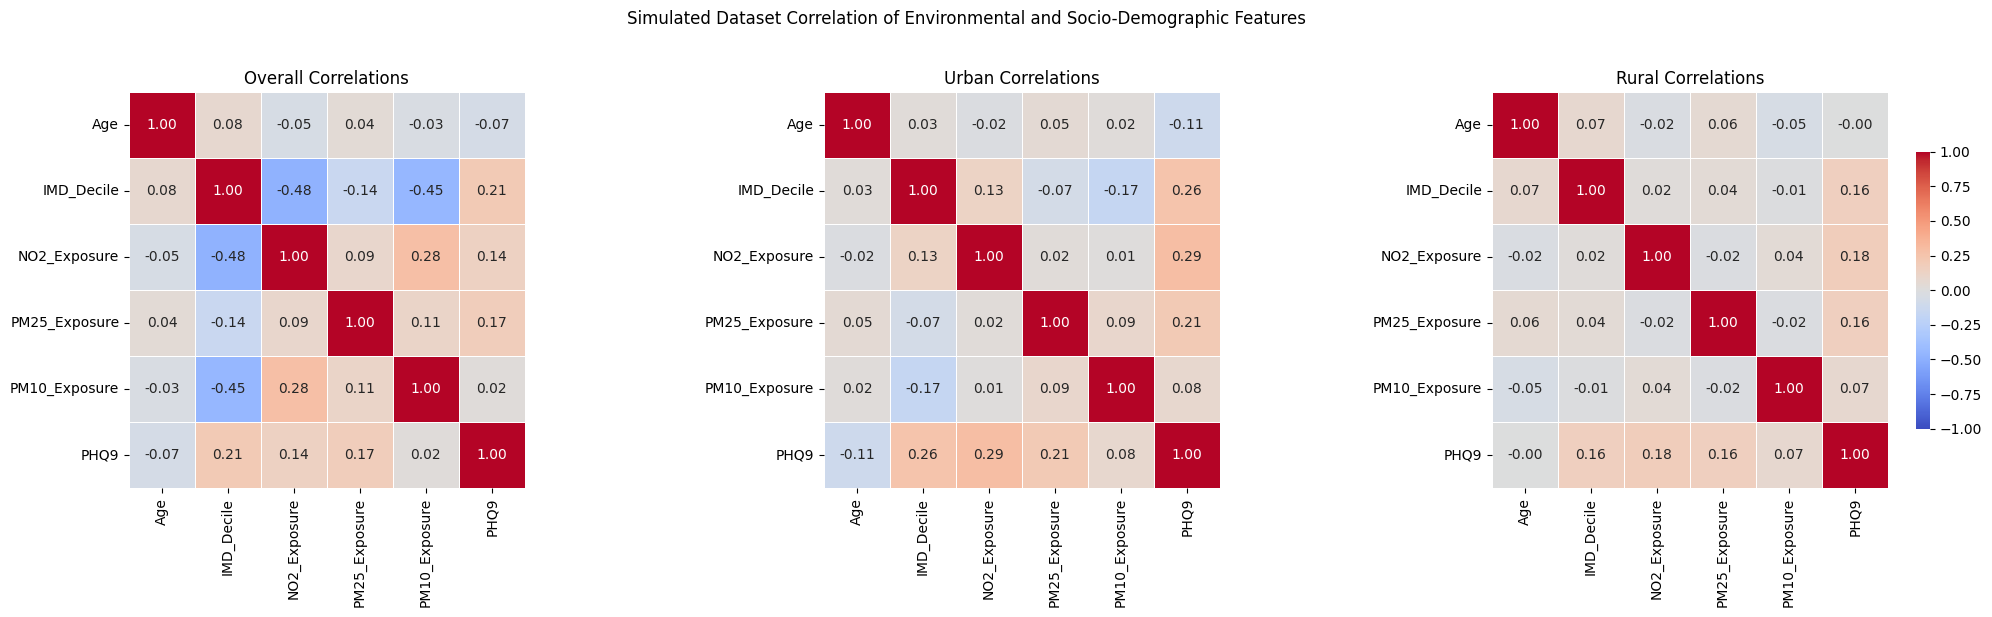

Mean pollutant exposure by area type:


,NO2_Exposure,PM25_Exposure,PM10_Exposure
Area_Type,,,
Rural,6.75,7.63,11.86
Urban,14.77,8.15,15.22


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compare correlations overall and by area type (Urban vs Rural)
corr_features = ['Age', 'IMD_Decile', 'NO2_Exposure', 'PM25_Exposure', 'PM10_Exposure', 'PHQ9']
df_corr = df.copy()
df_corr['Area_Type'] = np.where(df_corr['Urban_Rural_Status'].str.startswith('Urban'), 'Urban', 'Rural')

corr_all = df_corr[corr_features].corr(numeric_only=True)
corr_urban = df_corr.loc[df_corr['Area_Type'] == 'Urban', corr_features].corr(numeric_only=True)
corr_rural = df_corr.loc[df_corr['Area_Type'] == 'Rural', corr_features].corr(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.heatmap(
    corr_all,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=False,
    ax=axes[0]
)
axes[0].set_title('Overall Correlations')

sns.heatmap(
    corr_urban,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=False,
    ax=axes[1]
)
axes[1].set_title('Urban Correlations')

sns.heatmap(
    corr_rural,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7},
    ax=axes[2]
)
axes[2].set_title('Rural Correlations')

fig.suptitle('Simulated Dataset Correlation of Environmental and Socio-Demographic Features', y=1.02)
plt.tight_layout()
plt.show()

# Quick check of mean pollution levels by area type
pollution_summary = (
    df_corr
    .groupby('Area_Type')[['NO2_Exposure', 'PM25_Exposure', 'PM10_Exposure']]
    .mean()
    .round(2)
)
print('Mean pollutant exposure by area type:')
display(pollution_summary)

## Machine Learning Model
Model: Random Forest Regressor for PHQ-9 prediction. From Age, IMD Decile, Urban Rural Status, NO2, PM2.5, PM10 Exposure.
Categorical `Urban_Rural_Status` is one-hot encoded in a preprocessing pipeline with three catergories from ONS "Urban city and town", "Rural town and fringe", "Rural hamlets and isolated dwellings".

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X = df[['Age', 'IMD_Decile', 'Urban_Rural_Status', 'NO2_Exposure', 'PM25_Exposure', 'PM10_Exposure']]
y = df['PHQ9']

categorical_features = ['Urban_Rural_Status']
numeric_features = ['Age', 'IMD_Decile', 'NO2_Exposure', 'PM25_Exposure', 'PM10_Exposure']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', rf)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Model performance on test set, root mean squared error and variance:")
print(f'RMSE: {rmse:.3f}')
print(f'R^2:  {r2:.3f}')

Model performance on test set, root mean squared error and variance:
RMSE: 2.652
R^2:  0.094


## Model Explainability (SHAP)
SHAP values are used to inspect global feature importance and feature effect patterns, focusing on NO2, PM2.5. PM10 Exposure and deprivation.

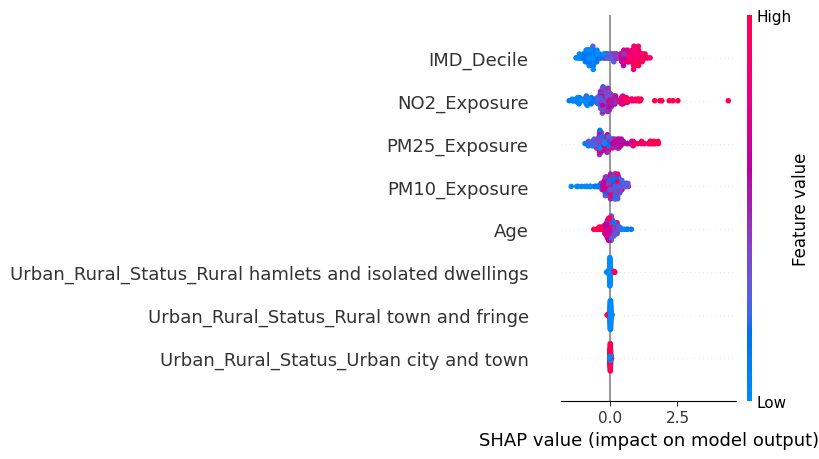

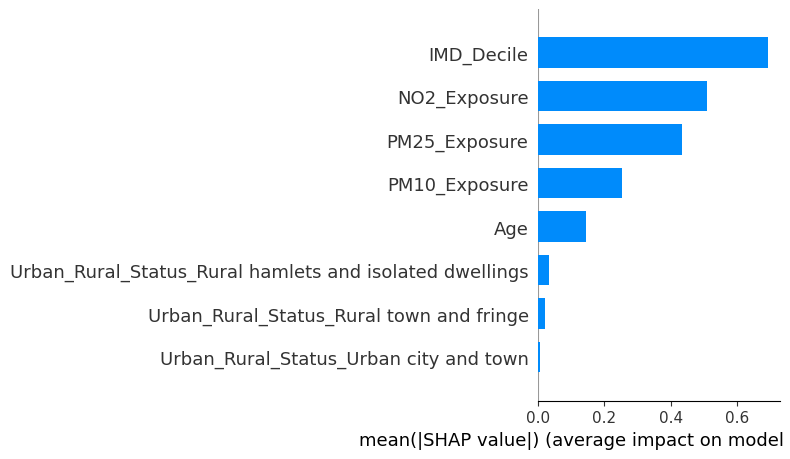

In [49]:
import shap

# Transform data using the fitted preprocessor
Xt_train = model.named_steps['preprocess'].transform(X_train)
Xt_test = model.named_steps['preprocess'].transform(X_test)

# Recover feature names after one-hot encoding
ohe = model.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(['Urban_Rural_Status'])
feature_names = list(cat_feature_names) + list(numeric_features)

rf_model = model.named_steps['model']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(Xt_test)

# Global feature importance
shap.summary_plot(shap_values, Xt_test, feature_names=feature_names)

# Bar chart version for quick ranking
shap.summary_plot(shap_values, Xt_test, feature_names=feature_names, plot_type='bar')

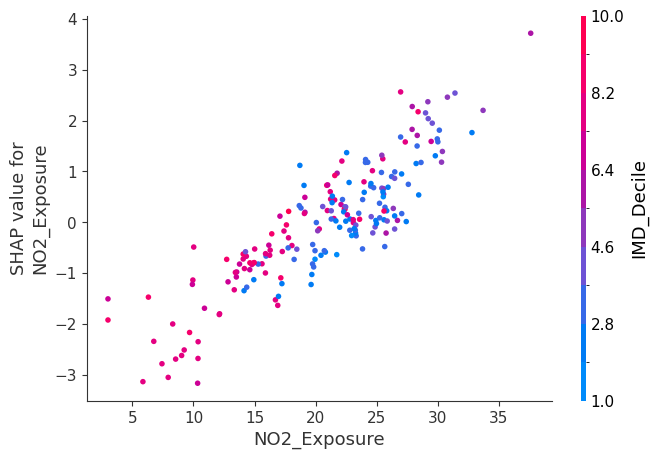

In [11]:
# Optional: dependence plot for NO2 contribution
if 'NO2_Exposure' in feature_names:
    no2_idx = feature_names.index('NO2_Exposure')
    shap.dependence_plot(no2_idx, shap_values, Xt_test, feature_names=feature_names)